# 02 · Loss Landscapes

Before benchmarking any optimizer it is essential to understand the **topology** of the objective function.  In this notebook we visualise the three canonical landscapes used throughout this series:

| Landscape | Key property | Why it's interesting |
|---|---|---|
| **Sphere** | Strictly convex | Trivial; baseline sanity check |
| **Ackley** | Highly multimodal | SA's showcase; GD gets trapped |
| **Rosenbrock** | Narrow curved valley | Hard for gradient methods; challenging for SA too |

In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.getcwd()), ''))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from simulated_annealing.landscapes import LANDSCAPES, sphere, ackley, rosenbrock
from simulated_annealing.utils import plot_landscape_3d, plot_landscape_contour

## 1  Sphere Function

$$f(x) = \sum_{i=1}^d x_i^2$$

- **Global minimum:** $f(0,\ldots,0) = 0$
- **Landscape:** perfectly convex bowl; no local minima
- **Purpose:** confirms every optimizer works on the easiest possible case

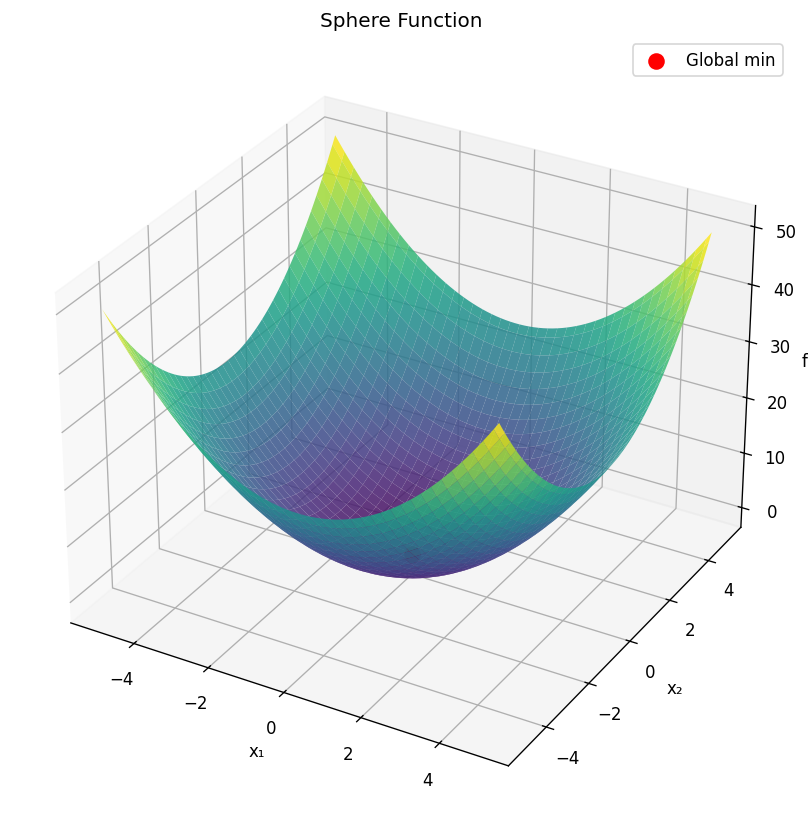

In [2]:
info = LANDSCAPES['sphere']
fig = plot_landscape_3d(sphere, info.bounds, title='Sphere Function', known_minimum=info.known_minimum)
plt.show()

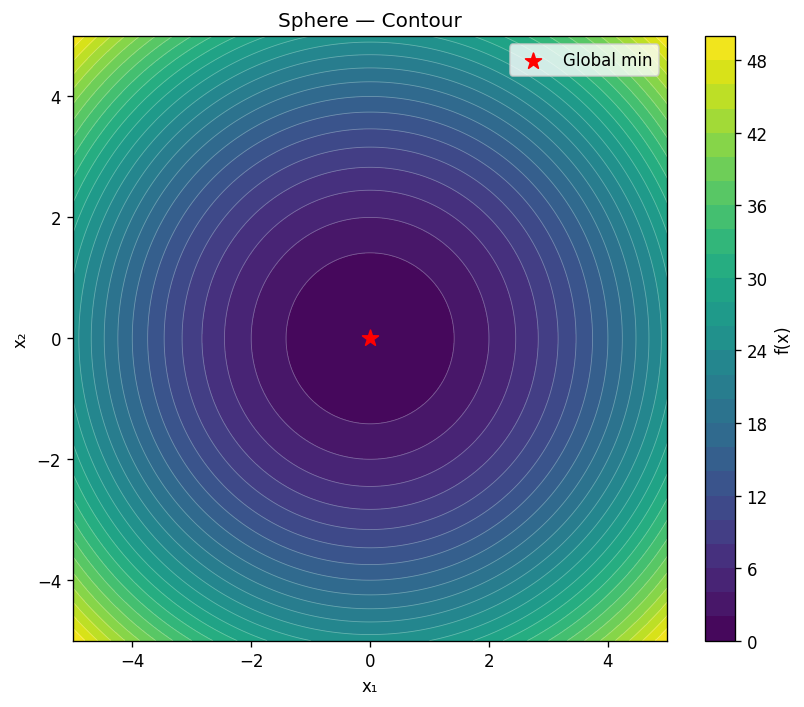

In [3]:
fig = plot_landscape_contour(sphere, info.bounds, title='Sphere — Contour', known_minimum=info.known_minimum)
plt.show()

## 2  Ackley Function

$$f(x) = -a \cdot e^{-b\sqrt{\frac{1}{d}\sum x_i^2}} - e^{\frac{1}{d}\sum \cos(c \cdot x_i)} + a + e$$

With $a=20, b=0.2, c=2\pi$.

- **Global minimum:** $f(0,\ldots,0) = 0$
- **Landscape:** flat outer region with many local minima, and a deep narrow well at the origin
- **Purpose:** exposes the weakness of gradient descent — it converges to whatever local minimum it starts near

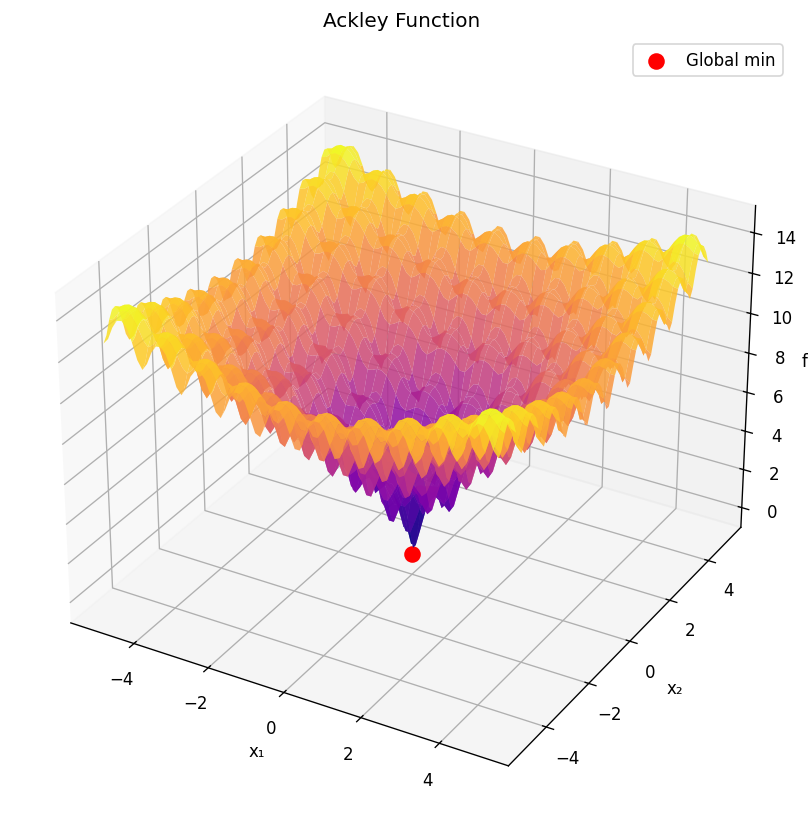

In [4]:
info = LANDSCAPES['ackley']
fig = plot_landscape_3d(ackley, info.bounds, title='Ackley Function', known_minimum=info.known_minimum, cmap='plasma')
plt.show()

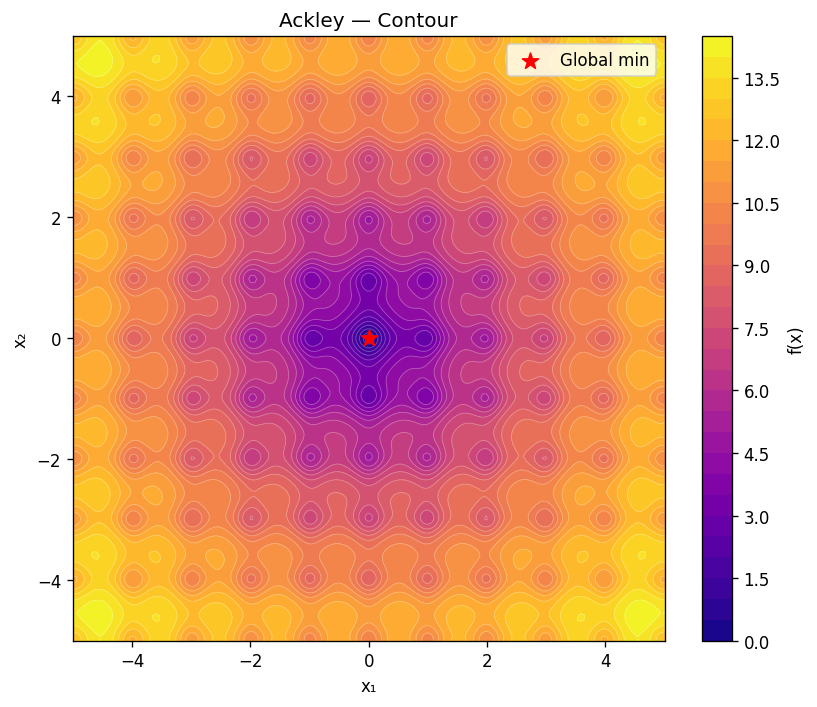

In [5]:
fig = plot_landscape_contour(ackley, info.bounds, title='Ackley — Contour', known_minimum=info.known_minimum, cmap='plasma')
plt.show()

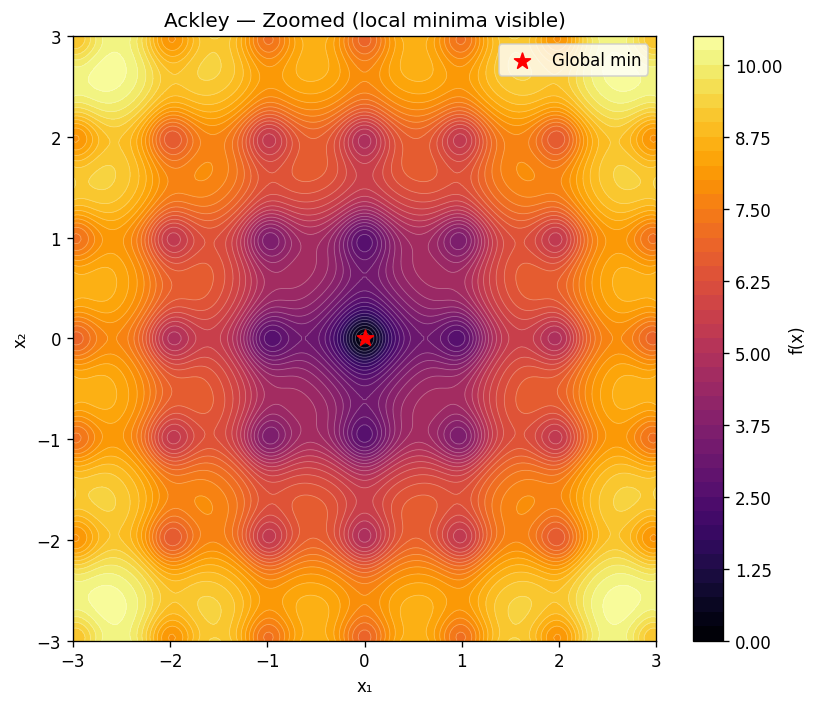

In [6]:
# Zoom in near the origin to see the local minima structure
fig = plot_landscape_contour(ackley, [(-3, 3), (-3, 3)],
                             title='Ackley — Zoomed (local minima visible)',
                             known_minimum=[0, 0], levels=50, cmap='inferno')
plt.show()

### How many local minima does Ackley have?

The number of local minima grows exponentially with dimension.  In 2-D, the cos term creates a grid of basins roughly at intervals of $2\pi / c = 1$ unit.  Over $[-5,5]^2$ that's on the order of **100+ local minima**.

Approximate number of local minima along x₂=0 slice: 10


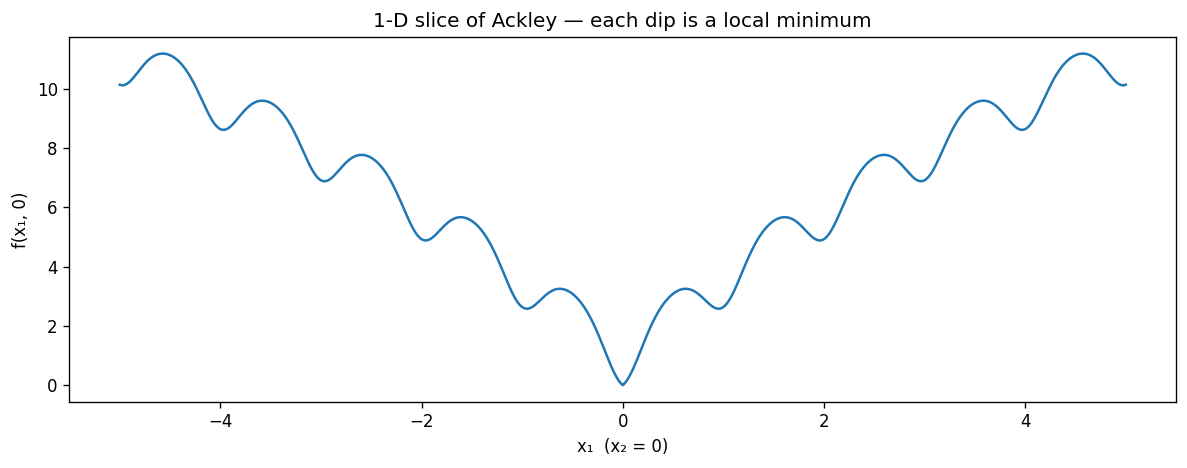

In [7]:
# Count approximate local minima in 1-D slice
xs = np.linspace(-5, 5, 5000)
fs = np.array([ackley([x, 0.0]) for x in xs])
# A local min is where the function decreases then increases
local_mins = np.sum((fs[1:-1] < fs[:-2]) & (fs[1:-1] < fs[2:]))
print(f"Approximate number of local minima along x₂=0 slice: {local_mins}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(xs, fs, linewidth=1.5)
ax.set_xlabel('x₁  (x₂ = 0)')
ax.set_ylabel('f(x₁, 0)')
ax.set_title('1-D slice of Ackley — each dip is a local minimum')
plt.tight_layout()
plt.show()

## 3  Rosenbrock Function

$$f(x) = \sum_{i=0}^{d-2} \left[ (1 - x_i)^2 + 100(x_{i+1} - x_i^2)^2 \right]$$

- **Global minimum:** $f(1,\ldots,1) = 0$
- **Landscape:** a narrow, curved (banana-shaped) valley.  The valley itself is easy to find; reaching the minimum along it is hard.
- **Purpose:** tests whether an optimizer can navigate a curved low-gradient channel

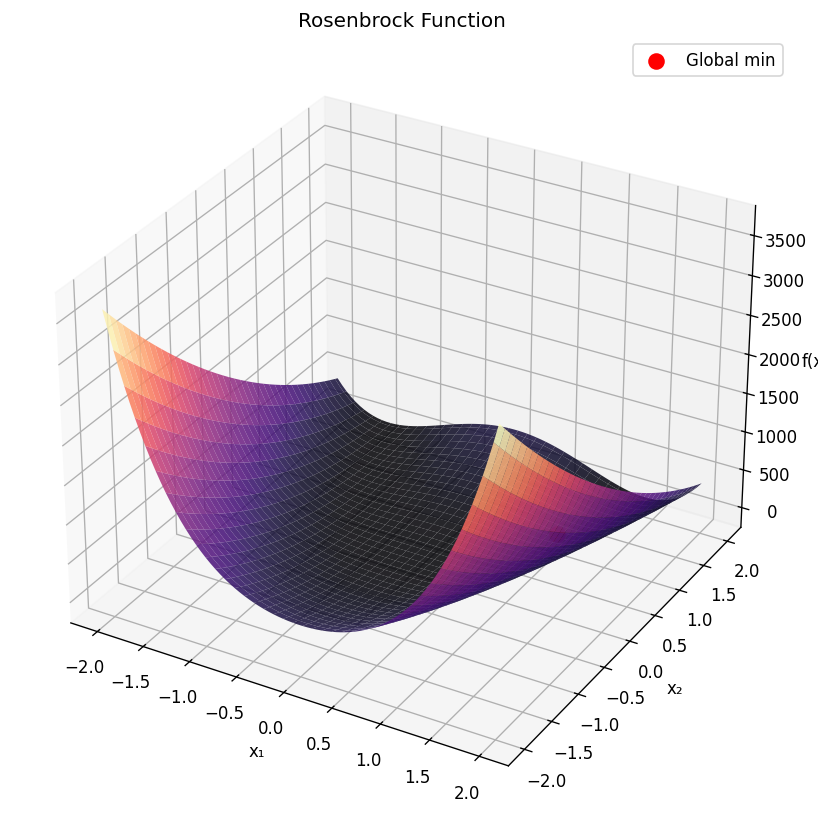

In [8]:
info = LANDSCAPES['rosenbrock']
fig = plot_landscape_3d(rosenbrock, info.bounds, title='Rosenbrock Function',
                        known_minimum=info.known_minimum, cmap='magma')
plt.show()

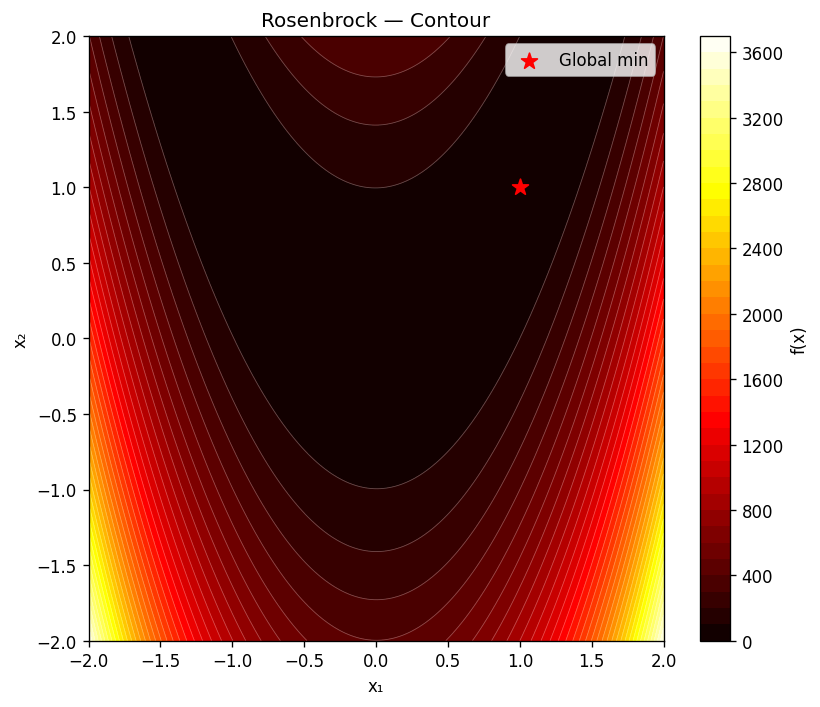

In [9]:
fig = plot_landscape_contour(rosenbrock, info.bounds, title='Rosenbrock — Contour',
                             known_minimum=info.known_minimum, levels=40, cmap='hot')
plt.show()

## 4  Side-by-side comparison

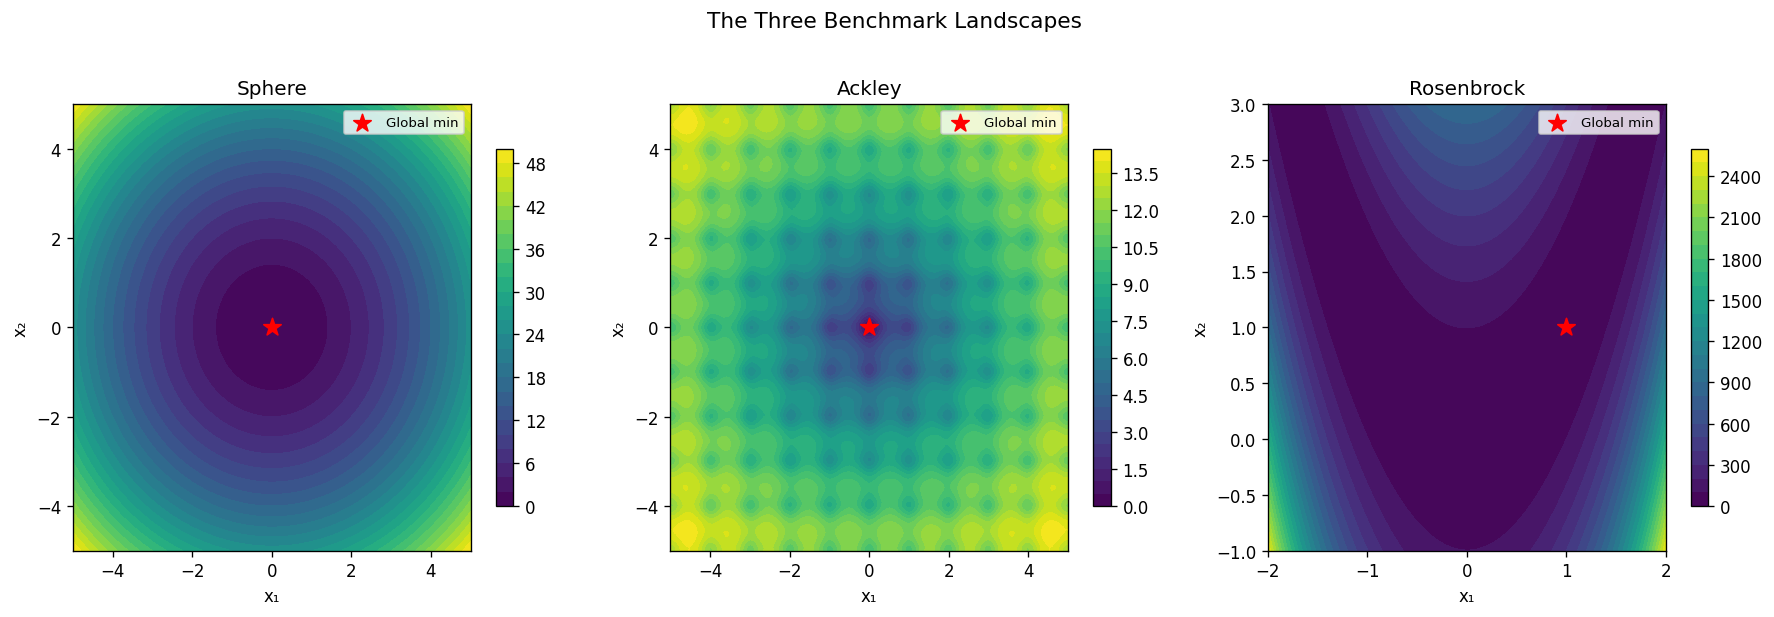

In [10]:
from simulated_annealing.utils.visualization import _make_grid

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
landscapes_to_plot = [
    ('Sphere', sphere, [(-5,5),(-5,5)], [0,0]),
    ('Ackley', ackley, [(-5,5),(-5,5)], [0,0]),
    ('Rosenbrock', rosenbrock, [(-2,2),(-1,3)], [1,1]),
]

for ax, (name, fn, bounds, opt) in zip(axes, landscapes_to_plot):
    X, Y, Z = _make_grid(fn, bounds, n_points=150)
    cf = ax.contourf(X, Y, Z, levels=30, cmap='viridis')
    ax.scatter(*opt, color='red', s=120, marker='*', zorder=5, label='Global min')
    ax.set_title(name)
    ax.set_xlabel('x₁')
    ax.set_ylabel('x₂')
    ax.legend(loc='upper right', fontsize=8)
    fig.colorbar(cf, ax=ax, shrink=0.8)

plt.suptitle('The Three Benchmark Landscapes', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Summary

| Function | Challenge | SA difficulty |
|---|---|---|
| Sphere | None | Easy — high acceptance rate converges quickly |
| Ackley | 100+ local minima | Medium — needs high initial T, slow cooling |
| Rosenbrock | Narrow curved valley | Hard — small steps miss the valley; large steps overshoot |

➡ **Next:** [03_sa_deep_dive.ipynb](03_sa_deep_dive.ipynb) — tracing the path SA takes and comparing cooling schedules.